# ResNet18 Cloud Filter — GCD Dataset

Runs the trained multi-head ResNet18 (head2) over every class folder in the GCD dataset
(both `train/` and `test/` splits) except `4_clearsky`.
Results are collected into a single CSV for downstream filtering.

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torchvision.models import ResNet18_Weights
from pathlib import Path
import numpy as np

class MultiHeadResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head1 = base.fc
        self.head2 = nn.Linear(512, num_classes)
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.head1.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x).flatten(1)
        return self.head1(features), self.head2(features)

SAVE_PATH = Path("../models/multihead_resnet18_cloud_sky.pth")
checkpoint = torch.load(SAVE_PATH, map_location="cpu", weights_only=False)
classes = checkpoint["classes"]   # ['clear_sky', 'cloud']
cloud_idx = classes.index("cloud")

imagenet_classes = ResNet18_Weights.IMAGENET1K_V1.meta["categories"]

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MultiHeadResNet18(num_classes=len(classes))
model.load_state_dict(checkpoint["model_state_dict"])
model.eval().to(device)

print(f"Model loaded. Classes: {classes}, device: {device}")

Model loaded. Classes: ['clear_sky', 'cloud'], device: mps


In [3]:
IMAGES_ROOT = Path("../resources/cloud-images/GCD")
SKIP_FOLDER = "4_clearsky"
CONF_THRESHOLD = 0.9
BATCH_SIZE = 64

# Collect (split, folder) pairs for both train and test, skipping clear sky
folder_entries = []
for split in ["train", "test"]:
    split_root = IMAGES_ROOT / split
    for folder in sorted(split_root.iterdir()):
        if folder.is_dir() and folder.name != SKIP_FOLDER:
            folder_entries.append((split, folder))

print(f"Folders to process ({len(folder_entries)}):")
for split, folder in folder_entries:
    n = len(list(folder.glob("*.jpg"))) + len(list(folder.glob("*.png"))) + len(list(folder.glob("*.jpeg")))
    print(f"  {split:5s}  {folder.name:20s}  {n:,} images")

Folders to process (12):
  train  1_cumulus             775 images
  train  2_altocumulus         725 images
  train  3_cirrus              1,153 images
  train  5_stratocumulus       1,846 images
  train  6_cumulonimbus        3,003 images
  train  7_mixed               348 images
  test   1_cumulus             750 images
  test   2_altocumulus         750 images
  test   3_cirrus              753 images
  test   5_stratocumulus       1,790 images
  test   6_cumulonimbus        2,761 images
  test   7_mixed               607 images


In [4]:
import cv2
from tqdm.auto import tqdm
from torch.nn.functional import softmax

preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

records = []

for split, folder in folder_entries:
    image_paths = (
        sorted(folder.glob("*.jpg"))
        + sorted(folder.glob("*.jpeg"))
        + sorted(folder.glob("*.png"))
    )
    print(f"\n{split}/{folder.name}: {len(image_paths):,} images")

    with torch.no_grad():
        for start in tqdm(range(0, len(image_paths), BATCH_SIZE)):
            batch_paths = image_paths[start:start + BATCH_SIZE]
            tensors, valid_paths = [], []
            for p in batch_paths:
                img = cv2.imread(str(p))
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                tensors.append(preprocess(img))
                valid_paths.append(p)

            if not tensors:
                continue

            batch = torch.stack(tensors).to(device)
            out1, out2 = model(batch)
            probs2 = softmax(out2, dim=1).cpu().numpy()
            probs1 = softmax(out1, dim=1).cpu().numpy()

            for p, prob2, prob1 in zip(valid_paths, probs2, probs1):
                top1_idx = int(np.argmax(prob1))
                records.append({
                    "split":      split,
                    "class":      folder.name,
                    "filename":   p.name,
                    "head2_pred": classes[int(np.argmax(prob2))],
                    "head2_conf": float(prob2[cloud_idx]),
                    "head1_pred": imagenet_classes[top1_idx],
                    "head1_conf": float(prob1[top1_idx]),
                })

print(f"\nDone. Total records: {len(records):,}")

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



train/1_cumulus: 775 images


100%|██████████| 13/13 [00:03<00:00,  3.34it/s]



train/2_altocumulus: 725 images


100%|██████████| 12/12 [00:01<00:00,  6.24it/s]


...


test/6_cumulonimbus: 2,761 images


100%|██████████| 44/44 [00:06<00:00,  7.10it/s]



test/7_mixed: 607 images


100%|██████████| 10/10 [00:01<00:00,  6.66it/s]


Done. Total records: 15,261


In [5]:
import pandas as pd

results_df = pd.DataFrame(records)

summary = (
    results_df.groupby(["split", "class"])
    .apply(lambda g: pd.Series({
        "total":     len(g),
        "cloud":     (g["head2_pred"] == "cloud").sum(),
        "not_cloud": (g["head2_pred"] == "clear_sky").sum(),
        "keep":      (g["head2_conf"] >= CONF_THRESHOLD).sum(),
        "keep_pct":  round(100 * (g["head2_conf"] >= CONF_THRESHOLD).sum() / len(g), 1),
    }), include_groups=False)
    .astype({"total": int, "cloud": int, "not_cloud": int, "keep": int})
)

print(summary.to_string())

                       total  cloud  not_cloud  keep  keep_pct
split class                                                   
test  1_cumulus          750    673         77   552      73.6
      2_altocumulus      750    710         40   575      76.7
      3_cirrus           753    434        319   232      30.8
      5_stratocumulus   1790   1125        665   438      24.5
      6_cumulonimbus    2761   2078        683   923      33.4
      7_mixed            607    587         20   504      83.0
train 1_cumulus          775    624        151   444      57.3
      2_altocumulus      725    652         73   382      52.7
      3_cirrus          1153    623        530   291      25.2
      5_stratocumulus   1846   1286        560   371      20.1
      6_cumulonimbus    3003   2565        438  1329      44.3
      7_mixed            348    330         18   282      81.0


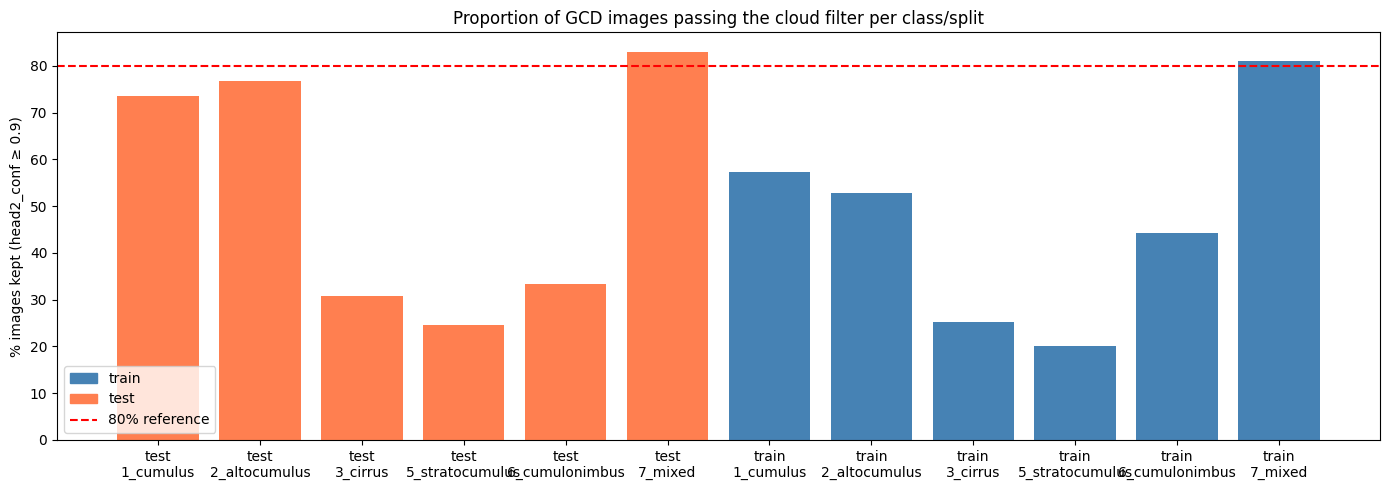

In [6]:
import matplotlib.pyplot as plt

# One bar per (split, class) combination
labels = [f"{s}\n{c}" for s, c in summary.index]
colors = ["steelblue" if s == "train" else "coral" for s, _ in summary.index]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(labels, summary["keep_pct"], color=colors)
ax.axhline(80, color="red", linestyle="--", label="80% reference")
ax.set_ylabel(f"% images kept (head2_conf ≥ {CONF_THRESHOLD})")
ax.set_title("Proportion of GCD images passing the cloud filter per class/split")
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color="steelblue", label="train"),
    plt.Rectangle((0,0),1,1, color="coral",     label="test"),
    plt.Line2D([0],[0], color="red", linestyle="--", label="80% reference"),
])
plt.tight_layout()
plt.show()

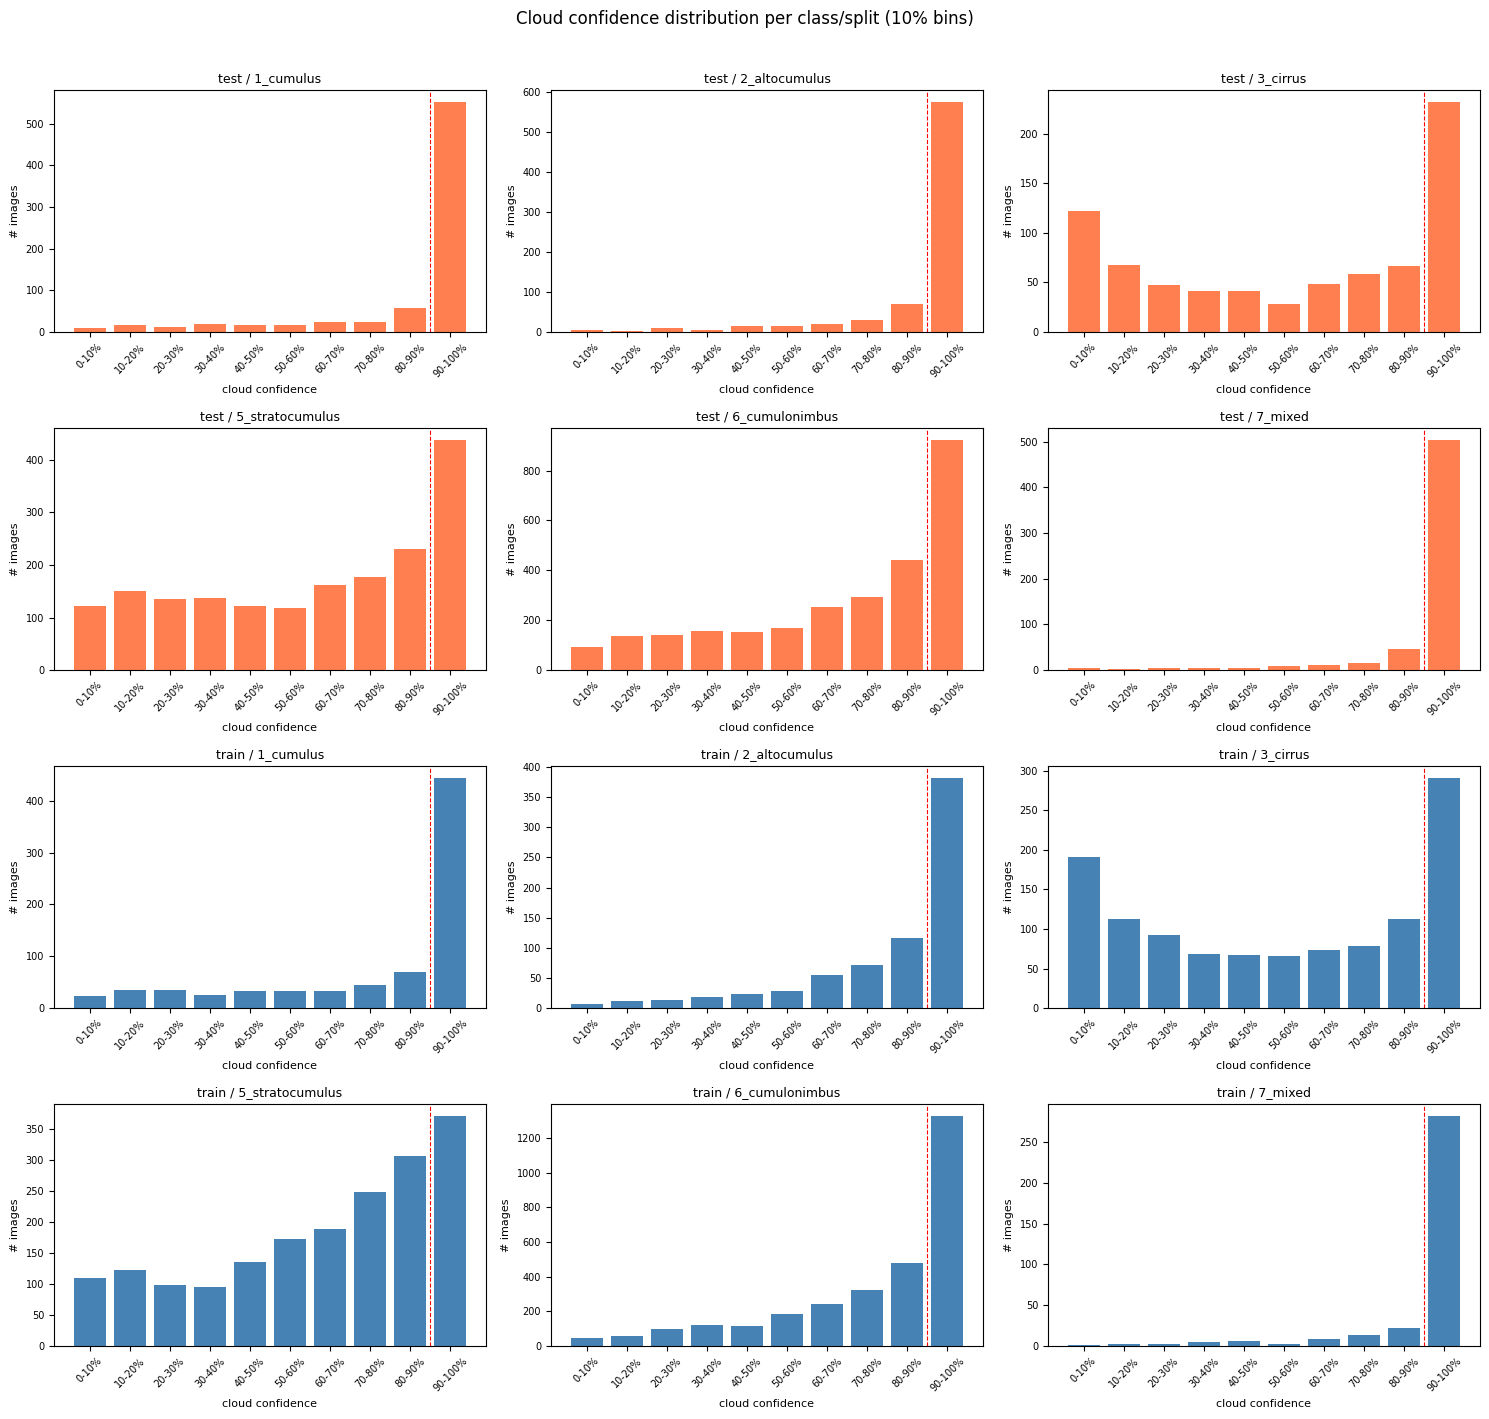

In [8]:
bins = [i / 10 for i in range(11)]  # [0.0, 0.1, ..., 1.0]
bin_labels = [f"{int(b*100)}-{int(b*100)+10}%" for b in bins[:-1]]

entries = sorted(results_df.groupby(["split", "class"]).groups.keys())
n_cols = 3
n_rows = -(-len(entries) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (split, cls) in zip(axes, entries):
    confs = results_df.loc[
        (results_df["split"] == split) & (results_df["class"] == cls),
        "head2_conf"
    ]
    counts, _ = np.histogram(confs, bins=bins)
    color = "steelblue" if split == "train" else "coral"
    ax.bar(bin_labels, counts, color=color)
    ax.set_title(f"{split} / {cls}", fontsize=9)
    ax.set_xlabel("cloud confidence", fontsize=8)
    ax.set_ylabel("# images", fontsize=8)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.axvline(x=8.5, color="red", linestyle="--", linewidth=0.8, label="90% threshold")

for ax in axes[len(entries):]:
    ax.set_visible(False)

fig.suptitle("Cloud confidence distribution per class/split (10% bins)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
EXPORT_PATH = IMAGES_ROOT / "gcd_cloud_filter_results.csv"
results_df.to_csv(EXPORT_PATH, index=False)
print(f"Exported {len(results_df):,} rows to {EXPORT_PATH}")
print(f"Clean images (head2_conf ≥ {CONF_THRESHOLD}): {(results_df['head2_conf'] >= CONF_THRESHOLD).sum():,}")

Exported 15,261 rows to ../resources/cloud-images/GCD/gcd_cloud_filter_results.csv
Clean images (head2_conf ≥ 0.9): 6,323
